In [462]:
from sklearn.datasets import make_classification
import numpy as np

In [463]:
X, y = make_classification(n_samples = 150, n_features = 2, n_informative=2, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=43, hypercube=True, class_sep=1)

In [464]:
import matplotlib.pyplot as plt

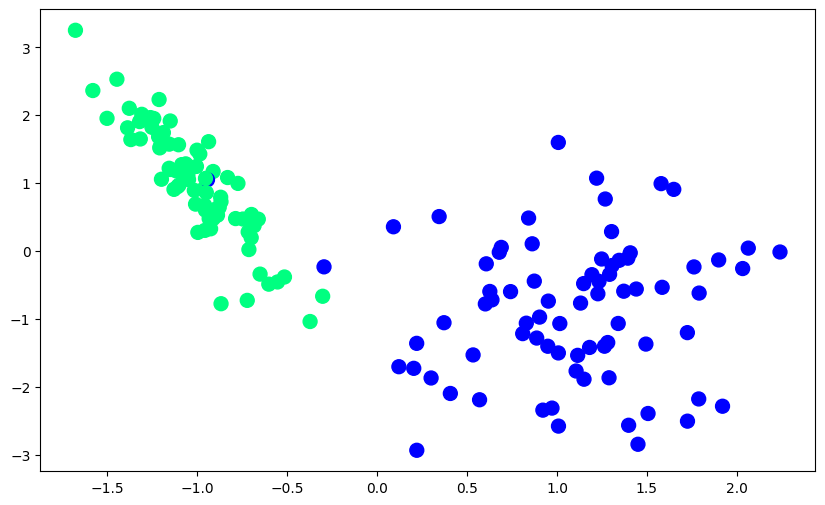

In [465]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [466]:
np.insert(X,0,1,axis=1)

array([[ 1.        ,  1.44061972, -0.55761399],
       [ 1.        , -0.95760918,  0.30575212],
       [ 1.        , -1.15200368,  1.20167778],
       [ 1.        ,  0.37154737, -1.05329484],
       [ 1.        , -0.91232605,  1.17224738],
       [ 1.        ,  1.30336737,  0.28753467],
       [ 1.        ,  1.79031073, -0.61718609],
       [ 1.        ,  0.20340262, -1.72484405],
       [ 1.        ,  1.40718784, -0.02503953],
       [ 1.        ,  1.2334095 , -0.44491315],
       [ 1.        , -0.96642162,  0.91064658],
       [ 1.        , -1.67774264,  3.25073708],
       [ 1.        ,  1.1810507 , -1.41734189],
       [ 1.        ,  1.76154081, -0.23233055],
       [ 1.        ,  0.60659929, -0.18671971],
       [ 1.        ,  1.78795745, -2.17550205],
       [ 1.        , -1.24241323,  1.95245416],
       [ 1.        ,  0.74164889, -0.59564464],
       [ 1.        , -1.20886135,  1.51978995],
       [ 1.        ,  0.69000427,  0.05501086],
       [ 1.        ,  1.58470751, -0.532

In [467]:
np.ones(X.shape[1])

array([1., 1.])

In [468]:
from PIL import Image
percep = Image.open("perceptron.png")

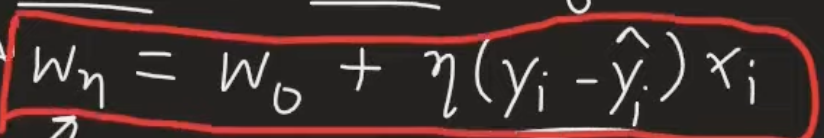

In [469]:
percep

In [470]:
def step(z):
    return 1 if z>0 else 0

In [471]:
def perceptron(X, y):
    X = np.insert(X,0,1,axis=1)
    #To input ones to multiply with bias term(intercept)
    weights = np.ones(X.shape[1])
    #X.shape[1] gets the number of columns in the tuple and return that number of ones as weights
    lr = 0.1

    for i in range(900):
        #running it for 1000 epochs
        j = np.random.randint(0,100)
        #chosses random point in dataseet
        y_hat = step(np.dot(X[j],weights))
        #dot product of weights and the row in X
        #step to return 1 if greater than 0 or return 0 if less than 0
        weights = weights + lr*(y[j]-y_hat)*X[j]
        #standard equation
    return weights[0],weights[1:]
    #returning intercept and coeffs

In [472]:
intercept_,coef_= perceptron(X,y)

In [473]:
print(intercept_,coef_)

-0.19999999999999993 [-0.65093939  0.01368104]


In [474]:
coco = Image.open("coco.png")

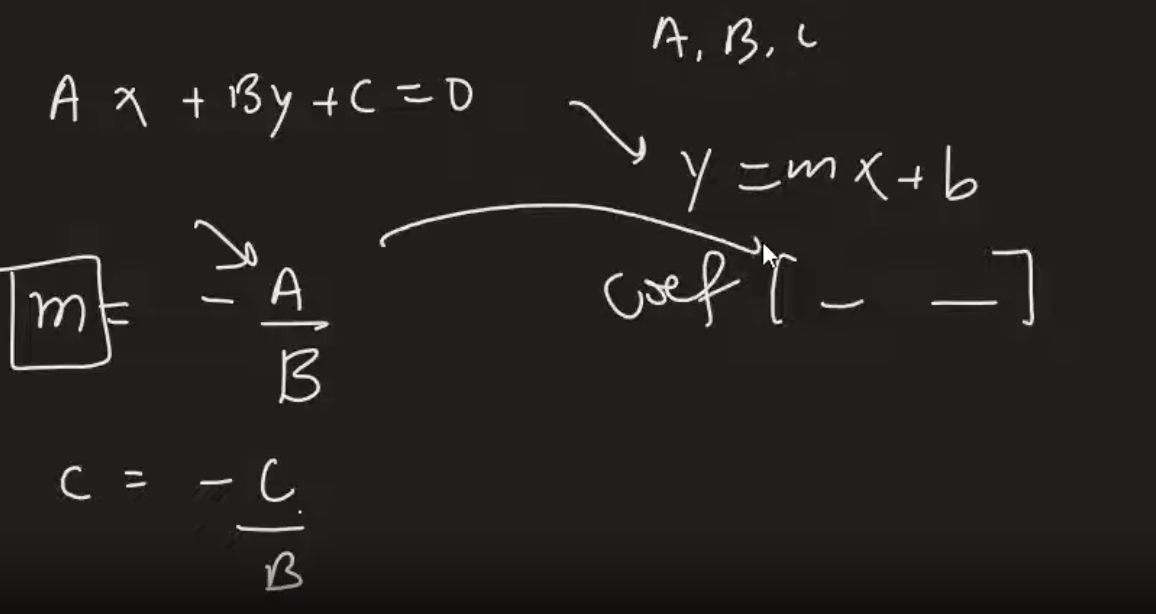

In [475]:
coco

In [476]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [477]:
x_input = np.linspace(-3,3,100)
#In range -3 to 3 using 100 points make a line
y_input = m*x_input + b

(-2.0, 2.5)

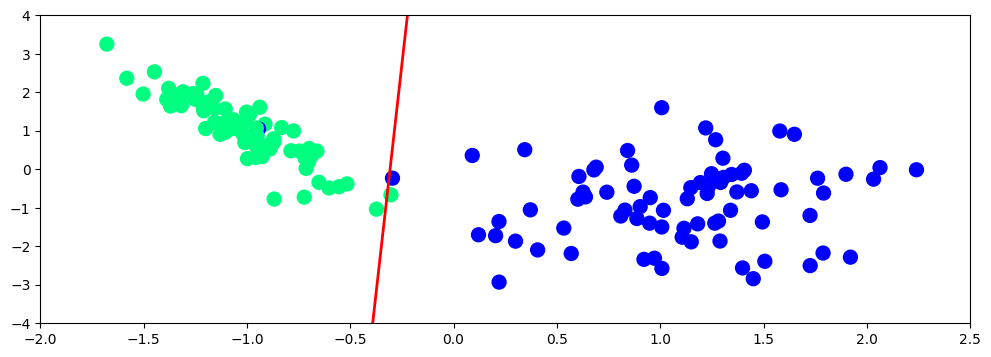

In [478]:
plt.figure(figsize=(12,4))
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-4,4)
plt.xlim(-2,2.5)

In [479]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [480]:
lr.coef_[0]

array([-3.19679275,  0.64371536])

In [481]:
lr.coef_[0][1]

np.float64(0.6437153628591321)

In [482]:
m = -(lr.coef_[0][0]/lr.coef_[0][1])
b = -(lr.intercept_/lr.coef_[0][1])

In [483]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-2.0, 2.5)

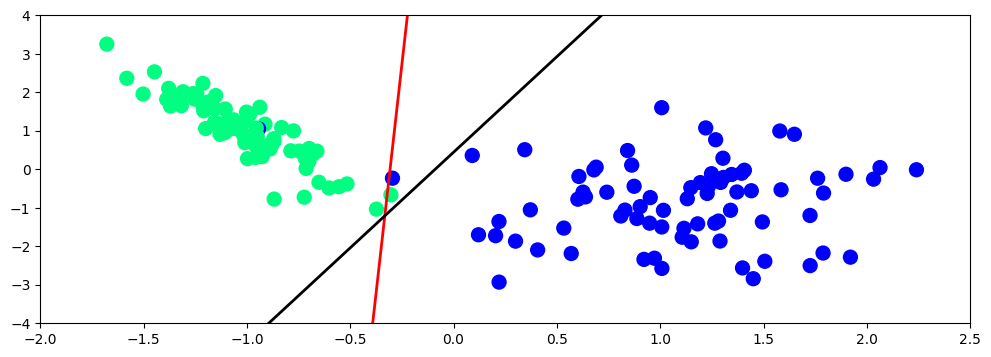

In [484]:
plt.figure(figsize=(12,4))
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.plot(x_input1,y_input1,color='black',linewidth=2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-4,4)
plt.xlim(-2,2.5)

In [ ]:
#The above graph shows that this way is not the most perfect one compared to sklearn which is performing better